# Building Energy Consumption Prediction: Batch ML Pipeline


## Overview

This notebook implements the **batch machine learning pipeline** for predicting hourly building energy consumption using Apache PySpark.

### Dataset
| File | Description |
|------|-------------|
| `data/meters.csv` | Hourly energy meter readings per building |
| `data/building_information.csv` | Building attributes (primary use, square footage, floor count, year built) |
| `data/weather.csv` | Hourly weather readings per site (temperature, wind speed, cloud coverage, pressure) |

### Pipeline Summary
1. **Data Loading** — Define schemas and load three CSVs into Spark DataFrames
2. **Aggregation** — Resample raw readings into 6-hour intervals
3. **Imputation** — Fill missing weather values using median imputation
4. **Feature Engineering** — One-hot encoding, cyclical time encoding, log transforms
5. **Model Training** — Compare Random Forest vs Gradient Boosted Trees
6. **Hyperparameter Tuning** — CrossValidator with ParamGridBuilder
7. **Model Persistence** — Save best pipeline to `models/energy_pipeline_model` for use by the streaming notebook


# Part 1: Data Loading, Transformation and Exploration <a class="anchor" name="part-1"></a>
## 1.1 Data Loading
In this section, you must load the given datasets into PySpark DataFrames and use DataFrame functions to process the data. For plotting, various visualisation packages can be used, but please ensure that you have included instructions to install the additional packages and that the installation will be successful in the provided Docker container (in case your marker needs to clear the notebook and rerun it).

### 1.1.1 Data Loading <a class="anchor" name="1.1"></a>
1.1.1 Write the code to create a SparkSession. For creating the SparkSession, you need to use a SparkConf object to configure the Spark app with a proper application name, to ensure the maximum partition size does not exceed 32MB, and to run locally with all CPU cores on your machine

In [1]:
# import the needed libraries
from pyspark.sql import SparkSession
from pyspark import SparkConf
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.ml.feature import Imputer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pyspark.ml.feature import OneHotEncoder, StringIndexer
import math
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [2]:
master = "local[*]"
app_name = "building-energy-batch"

# setup configuration parameters for Spark
spark_conf = (SparkConf().setMaster(master).setAppName(app_name).set("spark.sql.files.maxPartitionBytes", "32m"))

# create SparkSession
spark = SparkSession.builder.config(conf=spark_conf).getOrCreate()

26/06/24 14:07:49 WARN Utils: Your hostname, yundeMacBook-Air.local resolves to a loopback address: 127.0.0.1; using 192.168.213.55 instead (on interface en0)
26/06/24 14:07:49 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/24 14:07:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


1.1.2 Write code to define the schemas for the datasets, following the data types suggested in the metadata file. 

In [3]:
# meters.csv
meters_schema = StructType([
    StructField("building_id", IntegerType(), True),
    StructField("meter_type", StringType(), True),
    StructField("ts", TimestampType(), True),
    StructField("value", DoubleType(), True),
    StructField("row_id", IntegerType(), True)
])

In [4]:
# buildings.csv
buildings_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("building_id", IntegerType(), True),
    StructField("primary_use", StringType(), True),
    StructField("square_feet", IntegerType(), True),
    StructField("floor_count", IntegerType(), True),
    StructField("row_id", IntegerType(), True),
    StructField("year_built", IntegerType(), True),
    StructField("latent_y", DoubleType(), True),
    StructField("latent_s", DoubleType(), True),
    StructField("latent_r", DoubleType(), True)
])

In [5]:
# weather.csv
weather_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("timestamp", TimestampType(), True),
    StructField("air_temperature", DoubleType(), True),
    StructField("cloud_coverage", DoubleType(), True),
    StructField("dew_temperature", DoubleType(), True),
    StructField("sea_level_pressure", DoubleType(), True),
    StructField("wind_direction", DoubleType(), True),
    StructField("wind_speed", DoubleType(), True)
])

1.1.3 Using your schemas, load the CSV files into separate data frames. Print the schemas of all data frames. 

In [6]:
# meters
meters_df = spark.read.csv("data/meters.csv",header=True,schema=meters_schema)
print("Meters DataFrame Schema:")
meters_df.printSchema()

Meters DataFrame Schema:
root
 |-- building_id: integer (nullable = true)
 |-- meter_type: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- value: double (nullable = true)
 |-- row_id: integer (nullable = true)



In [7]:
# buildings
buildings_df = spark.read.csv("data/building_information.csv",header=True,schema=buildings_schema)
print("Buildings DataFrame Schema:")
buildings_df.printSchema()

Buildings DataFrame Schema:
root
 |-- site_id: integer (nullable = true)
 |-- building_id: integer (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- row_id: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: double (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: double (nullable = true)



In [8]:
# weather
weather_df = spark.read.csv("data/weather.csv",header=True,schema=weather_schema)
print("Weather DataFrame Schema:")
weather_df.printSchema()

Weather DataFrame Schema:
root
 |-- site_id: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- air_temperature: double (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: double (nullable = true)
 |-- sea_level_pressure: double (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: double (nullable = true)



### 1.2 Data Transformation to Create Features <a class="anchor" name="1.2"></a>
In this section, we primarily have three tasks:  
1.2.1 The dataset includes sensors with hourly energy measurements. However, as a grid operator, we don’t need this level of granularity and lowering it can reduce the amount of data we need to process. For each building, we will aggregate the metered energy consumption in 6-hour intervals (0:00-5:59, 6:00-11:59, 12:00-17:59, 18:00-23:59). This will be our target (label) column for this prediction. Perform the aggregation for each building.


In [9]:
meters_df.show()

+-----------+----------+-------------------+-------+------+
|building_id|meter_type|                 ts|  value|row_id|
+-----------+----------+-------------------+-------+------+
|        161|         c|2022-01-01 00:00:00|    0.0|     1|
|        162|         c|2022-01-01 00:00:00|    0.0|     2|
|        166|         c|2022-01-01 00:00:00|209.886|     4|
|        167|         c|2022-01-01 00:00:00|    0.0|     5|
|        168|         c|2022-01-01 00:00:00| 51.557|     6|
|        169|         c|2022-01-01 00:00:00|176.686|     7|
|        173|         c|2022-01-01 00:00:00|19.3427|    11|
|        176|         c|2022-01-01 00:00:00|    0.0|    14|
|        177|         c|2022-01-01 00:00:00|130.686|    15|
|        178|         c|2022-01-01 00:00:00| 5.8731|    16|
|        180|         c|2022-01-01 00:00:00|20.3274|    18|
|        181|         c|2022-01-01 00:00:00|12.5903|    19|
|        183|         c|2022-01-01 00:00:00|13.0827|    20|
|        187|         c|2022-01-01 00:00

In [10]:
# aggregate 6-hour intervals for energy consumption
meters_labeled = (
    meters_df
    .withColumn("year", F.year("ts"))
    .withColumn("month", F.month("ts"))
    .withColumn("day", F.dayofmonth("ts"))
    .withColumn("hour", F.hour("ts"))
    .withColumn("time_interval", 
                F.when((F.col("hour") >= 0) & (F.col("hour") < 6), "0:00-5:59")
                 .when((F.col("hour") >= 6) & (F.col("hour") < 12), "6:00-11:59")
                 .when((F.col("hour") >= 12) & (F.col("hour") < 18), "12:00-17:59")
                 .otherwise("18:00-23:59")
               )
    .groupBy("building_id","meter_type", "year", "month", "day", "time_interval")
    .agg(F.sum("value").alias("energy_consumption"))
)

meters_labeled.show(10)

+-----------+----------+----+-----+---+-------------+------------------+
|building_id|meter_type|year|month|day|time_interval|energy_consumption|
+-----------+----------+----+-----+---+-------------+------------------+
|       1107|         c|2022|    1|  1|   6:00-11:59|               0.0|
|       1220|         c|2022|    1|  1|   6:00-11:59| 94.62880000000001|
|        995|         c|2022|    1|  1|  12:00-17:59|            47.794|
|       1240|         c|2022|    1|  1|  12:00-17:59|4078.0199999999995|
|        257|         c|2022|    1|  1|  18:00-23:59|22.367199999999997|
|        913|         c|2022|    1|  1|  18:00-23:59| 859.9760000000001|
|        899|         c|2022|    1|  2|    0:00-5:59|          277.7959|
|        995|         c|2022|    1|  2|    0:00-5:59|           45.2619|
|       1266|         c|2022|    1|  2|    0:00-5:59|0.5820000000000001|
|        287|         c|2022|    1|  2|   6:00-11:59|13.188099999999999|
+-----------+----------+----+-----+---+------------

In the weather dataset, there are some missing values (null or empty strings). It may lower the quality of our model. Imputation is a way to deal with those missing values. Imputation is the process of replacing missing values in a dataset with substituted, or "imputed," values. It's a way to handle gaps in your data so that you can still analyse it effectively without having to delete incomplete records.  
1.2.2 Refer to the Spark MLLib imputation API and fill in the missing values in the weather dataset. You can use mean values as the strategy.  https://spark.apache.org/docs/3.5.5/api/python/reference/api/pyspark.ml.feature.Imputer.html

In [11]:
# check the dataframe
weather_df.show()

+-------+-------------------+---------------+--------------+---------------+------------------+--------------+----------+
|site_id|          timestamp|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+-------+-------------------+---------------+--------------+---------------+------------------+--------------+----------+
|      0|2022-01-01 22:00:00|           26.7|          null|           18.3|            1016.9|         230.0|       3.1|
|      0|2022-01-01 23:00:00|           25.6|          null|           18.3|            1017.5|         230.0|       3.1|
|      0|2022-01-02 00:00:00|           24.4|           6.0|           18.9|            1018.1|         270.0|       2.6|
|      0|2022-01-02 01:00:00|           23.9|           4.0|           18.3|            1018.5|         300.0|       2.1|
|      0|2022-01-02 02:00:00|           22.2|          null|           19.4|              null|         360.0|       5.7|
|      0|2022-01-02 03:0

In [12]:
# find the missing values
missing_values = (weather_df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in weather_df.columns]))
missing_values.show()

+-------+---------+---------------+--------------+---------------+------------------+--------------+----------+
|site_id|timestamp|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+-------+---------+---------------+--------------+---------------+------------------+--------------+----------+
|      0|        0|             55|         69173|            113|             10618|          6268|       304|
+-------+---------+---------------+--------------+---------------+------------------+--------------+----------+



In [13]:
# select the row with missing values
input_cols = ["air_temperature","cloud_coverage","dew_temperature","sea_level_pressure","wind_direction","wind_speed"]
# define the imputer
imputer = Imputer(inputCols=input_cols, outputCols=input_cols).setStrategy("mean")
# apply to weather dataframe
weather_imputed = imputer.fit(weather_df).transform(weather_df)
# check the result
missing_values = (weather_imputed.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in weather_df.columns]))
missing_values.show()

+-------+---------+---------------+--------------+---------------+------------------+--------------+----------+
|site_id|timestamp|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+-------+---------+---------------+--------------+---------------+------------------+--------------+----------+
|      0|        0|              0|             0|              0|                 0|             0|         0|
+-------+---------+---------------+--------------+---------------+------------------+--------------+----------+



We know that different seasons may affect energy consumption—for instance, a heater in winter and a cooler in summer. Extracting peak seasons (summer and winter) or off-peak seasons (Spring and Autumn) might be more useful than directly using the month as numerical values.   
1.2.3 The dataset has 16 sites in total, whose locations may span across different countries. Add a column (peak/off-peak) to the weather data frame based on the average air temperature. The top 3 hottest months and the 3 coldest months are considered “peak”, and the rest of the year is considered “off-peak”. 

In [14]:
# find month from timestamp
weather_month = weather_imputed.withColumn("month", F.month("timestamp"))

# calculate the avg temp
monthly_avg_temp = (weather_month.groupBy("month").agg(F.avg("air_temperature").alias("avg_temp"))
                    .orderBy("avg_temp", ascending=False))
# find the hottest and coldest
hottest_months = [row["month"] for row in monthly_avg_temp.take(3)] # first 3 with descending are the hottest
coldest_months = [row["month"] for row in monthly_avg_temp.orderBy("avg_temp").take(3)] # first 3 with ascending are the coldest

# add (peak/off-peak) column
weather_labeled = weather_month.withColumn("peak/off-peak",F.when(F.col("month").isin(hottest_months + coldest_months), "peak")
                                           .otherwise("off-peak"))
# check the result
weather_labeled.show(10)

+-------+-------------------+---------------+------------------+---------------+------------------+--------------+----------+-----+-------------+
|site_id|          timestamp|air_temperature|    cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|month|peak/off-peak|
+-------+-------------------+---------------+------------------+---------------+------------------+--------------+----------+-----+-------------+
|      0|2022-01-01 22:00:00|           26.7|2.1493059490084985|           18.3|            1016.9|         230.0|       3.1|    1|         peak|
|      0|2022-01-01 23:00:00|           25.6|2.1493059490084985|           18.3|            1017.5|         230.0|       3.1|    1|         peak|
|      0|2022-01-02 00:00:00|           24.4|               6.0|           18.9|            1018.1|         270.0|       2.6|    1|         peak|
|      0|2022-01-02 01:00:00|           23.9|               4.0|           18.3|            1018.5|         300.0|       2.1

Create a data frame with all relevant columns at this stage, we refer to this data frame as feature_df.

In [15]:
# check building df to see how to join
buildings_df.show()

+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
|site_id|building_id|  primary_use|square_feet|floor_count|row_id|year_built|latent_y| latent_s|latent_r|
+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
|      2|        165|    Warehouse|       3877|          1|   166|      1982|    18.0|3.5884957|     3.0|
|      2|        229|    Education|     140092|          1|   230|      1999|     1.0|5.1464133|     3.0|
|      1|        121|    Education|     150318|          9|   122|      1913|    87.0|4.2227683|     2.0|
|      8|        871|Entertainment|       1536|          1|   872|      1974|    26.0| 3.186391|     4.0|
|      9|        939|  Residential|       8051|          1|   940|      1980|    20.0|  3.90585|     4.0|
|      5|        675|   Industrial|       3853|          1|   676|      1983|    17.0| 3.585799|     4.0|
|      3|        311|    Education|      50000

In [16]:
# dataframe of meters and buildings are joined by building_id 
feature_df = meters_labeled.join(buildings_df, on="building_id", how="left")

In [17]:
# create aggregate 6-hour intervals for waether to join with the same time period
weather_label = (
    weather_labeled  
    .withColumn("year", F.year("timestamp"))
    .withColumn("month", F.month("timestamp"))
    .withColumn("day", F.dayofmonth("timestamp"))
    .withColumn("hour", F.hour("timestamp"))
    .withColumn(
        "time_interval",
        F.when((F.col("hour") >= 0) & (F.col("hour") < 6), "0:00-5:59")
         .when((F.col("hour") >= 6) & (F.col("hour") < 12), "6:00-11:59")
         .when((F.col("hour") >= 12) & (F.col("hour") < 18), "12:00-17:59")
         .otherwise("18:00-23:59")
    )
    .groupBy("site_id", "year", "month", "day", "time_interval", "peak/off-peak")
    .agg(
        F.avg("air_temperature").alias("air_temperature"),
        F.avg("cloud_coverage").alias("cloud_coverage"),
        F.avg("dew_temperature").alias("dew_temperature"),
        F.avg("sea_level_pressure").alias("sea_level_pressure"),
        F.avg("wind_direction").alias("wind_direction"),
        F.avg("wind_speed").alias("wind_speed")
    )
)

In [18]:
weather_label.show(5)

+-------+----+-----+---+-------------+-------------+------------------+------------------+------------------+------------------+------------------+------------------+
|site_id|year|month|day|time_interval|peak/off-peak|   air_temperature|    cloud_coverage|   dew_temperature|sea_level_pressure|    wind_direction|        wind_speed|
+-------+----+-----+---+-------------+-------------+------------------+------------------+------------------+------------------+------------------+------------------+
|      0|2022|    2|  2|  12:00-17:59|         peak| 19.98333333333333| 4.716435316336167|18.400000000000002|1019.0999999999999|             100.0|2.2166666666666663|
|      0|2022|    2|  9|  12:00-17:59|         peak|10.933333333333332| 3.074652974504249|             -2.85|            1017.4|             290.0| 7.116666666666667|
|      0|2022|    2| 19|  18:00-23:59|         peak|21.383333333333336| 3.099537299338999| 8.866666666666667|1027.5000000000002| 88.33333333333333| 6.266666666666667

In [19]:
# join weather dataframe
feature_df = feature_df.join(weather_label,on=["site_id","year","month","day","time_interval"],how="left")

In [20]:
feature_df.show()

+-------+----+-----+---+-------------+-----------+----------+------------------+-------------+-----------+-----------+------+----------+--------+---------+--------+-------------+--------------------+------------------+-------------------+------------------+------------------+------------------+
|site_id|year|month|day|time_interval|building_id|meter_type|energy_consumption|  primary_use|square_feet|floor_count|row_id|year_built|latent_y| latent_s|latent_r|peak/off-peak|     air_temperature|    cloud_coverage|    dew_temperature|sea_level_pressure|    wind_direction|        wind_speed|
+-------+----+-----+---+-------------+-----------+----------+------------------+-------------+-----------+-----------+------+----------+--------+---------+--------+-------------+--------------------+------------------+-------------------+------------------+------------------+------------------+
|     13|2022|    1|  1|   6:00-11:59|       1107|         c|               0.0|    Education|     184098|      

### 1.3 Exploring the Data <a class="anchor" name="1.3"></a>
You can use either the CDA or the EDA method mentioned in Lab 5.  
Some ideas for CDA:  
a)	Older building may not be as efficient as new ones, therefore need more energy for cooling/heating. It’s not necessarily true though, if the buildings are built with higher standard or renovated later.  
b)	A multifloored or larger building obviously consumes more energy.  

1.	With the feature_df, write code to show the basic statistics:  
a) For each numeric column, show count, mean, stddev, min, max, 25 percentile, 50 percentile, 75 percentile;  
b) For each non-numeric column, display the top-5 values and the corresponding counts;  
c) For each boolean column, display the value and count. (note: pandas describe is allowed for this task.) (5%)

In [21]:
# check the missing value
missing_values = (feature_df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in feature_df.columns]))
missing_values.show()

+-------+----+-----+---+-------------+-----------+----------+------------------+-----------+-----------+-----------+------+----------+--------+--------+--------+-------------+---------------+--------------+---------------+------------------+--------------+----------+
|site_id|year|month|day|time_interval|building_id|meter_type|energy_consumption|primary_use|square_feet|floor_count|row_id|year_built|latent_y|latent_s|latent_r|peak/off-peak|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+-------+----+-----+---+-------------+-----------+----------+------------------+-----------+-----------+-----------+------+----------+--------+--------+--------+-------------+---------------+--------------+---------------+------------------+--------------+----------+
|      0|   0|    0|  0|            0|          0|         0|                 0|          0|          0|          0|     0|         0|       0|       0|       0|         2436|           2436|     

In [22]:
# fill peak/off-peak by month
feature_df = feature_df.withColumn("peak/off-peak",F.when(F.col("month").isin(hottest_months + coldest_months), "peak")
                                           .otherwise("off-peak"))
# fill other weather data with mean
weather_cols = ["air_temperature","cloud_coverage","dew_temperature","sea_level_pressure","wind_direction","wind_speed"]
imputer = Imputer(inputCols=weather_cols, outputCols=weather_cols).setStrategy("mean")
feature_df = imputer.fit(feature_df).transform(feature_df)
# check missing value again
missing_values = (feature_df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in feature_df.columns]))
missing_values.show()

+-------+----+-----+---+-------------+-----------+----------+------------------+-----------+-----------+-----------+------+----------+--------+--------+--------+-------------+---------------+--------------+---------------+------------------+--------------+----------+
|site_id|year|month|day|time_interval|building_id|meter_type|energy_consumption|primary_use|square_feet|floor_count|row_id|year_built|latent_y|latent_s|latent_r|peak/off-peak|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+-------+----+-----+---+-------------+-----------+----------+------------------+-----------+-----------+-----------+------+----------+--------+--------+--------+-------------+---------------+--------------+---------------+------------------+--------------+----------+
|      0|   0|    0|  0|            0|          0|         0|                 0|          0|          0|          0|     0|         0|       0|       0|       0|            0|              0|     

In [23]:
feature_df.dtypes

[('site_id', 'int'),
 ('year', 'int'),
 ('month', 'int'),
 ('day', 'int'),
 ('time_interval', 'string'),
 ('building_id', 'int'),
 ('meter_type', 'string'),
 ('energy_consumption', 'double'),
 ('primary_use', 'string'),
 ('square_feet', 'int'),
 ('floor_count', 'int'),
 ('row_id', 'int'),
 ('year_built', 'int'),
 ('latent_y', 'double'),
 ('latent_s', 'double'),
 ('latent_r', 'double'),
 ('peak/off-peak', 'string'),
 ('air_temperature', 'double'),
 ('cloud_coverage', 'double'),
 ('dew_temperature', 'double'),
 ('sea_level_pressure', 'double'),
 ('wind_direction', 'double'),
 ('wind_speed', 'double')]

### numeric column

In [24]:
# transfer to pandas
pd_feature_df = feature_df.toPandas()

In [25]:
# show the stats
stats = pd_feature_df.describe(percentiles=[.25, .5, .75]).T
print(stats)

                        count           mean           std          min  \
site_id             2302986.0       7.864068  5.144312e+00     0.000000   
year                2302986.0    2022.000000  0.000000e+00  2022.000000   
month               2302986.0       6.587437  3.432885e+00     1.000000   
day                 2302986.0      15.731204  8.806387e+00     1.000000   
building_id         2302986.0     787.409668  4.334709e+02     0.000000   
energy_consumption  2302986.0   16940.337318  1.104024e+06     0.000000   
square_feet         2302986.0  104585.147842  1.117486e+05   356.000000   
floor_count         2302986.0       1.548496  2.068043e+00     1.000000   
row_id              2302986.0     788.409668  4.334709e+02     1.000000   
year_built          2302986.0    1987.890886  2.527514e+01  1907.000000   
latent_y            2302986.0      21.212088  1.831695e+01     0.000000   
latent_s            2302986.0       4.701737  5.450069e-01     2.551450   
latent_r            23029

In [26]:
# remove the outliers in energy_consumption by std
print("Row count before remove outliers:", feature_df.count())
# get mean and std value
stats = feature_df.select( F.mean("energy_consumption"), F.stddev("energy_consumption")).first()
mean_val, std_val = stats[0], stats[1]
# remove the outliers
feature_df = feature_df.filter(
    (F.col("energy_consumption") <= mean_val + 3*std_val) &
    (F.col("energy_consumption") >= mean_val - 3*std_val)
)
print("Row count after remove outliers:", feature_df.count())

Row count before remove outliers: 2302986


Row count after remove outliers: 2302439


### non-numeric column

In [27]:
categorical_cols = ["primary_use", "time_interval","meter_type"]
# print top 5 values and their counts
for col in categorical_cols:
    print(f"Top 5 values for {col}:")
    feature_df.groupBy(col).count().orderBy(F.desc("count")).show(5)
    
# peak and off-peak column
print(f"values for peak/off-peak:",)
feature_df.groupBy("peak/off-peak").count().show()

Top 5 values for primary_use:


+-------------+------+
|  primary_use| count|
+-------------+------+
|    Education|910517|
|       Office|459543|
|  Residential|275247|
|Entertainment|270287|
|    Community|211558|
+-------------+------+
only showing top 5 rows

Top 5 values for time_interval:


+-------------+------+
|time_interval| count|
+-------------+------+
|   6:00-11:59|575782|
|  12:00-17:59|575720|
|  18:00-23:59|575649|
|    0:00-5:59|575288|
+-------------+------+

Top 5 values for meter_type:


+----------+-------+
|meter_type|  count|
+----------+-------+
|         e|1387776|
|         c| 468561|
|         s| 297977|
|         h| 148125|
+----------+-------+

values for peak/off-peak:


+-------------+-------+
|peak/off-peak|  count|
+-------------+-------+
|     off-peak|1157311|
|         peak|1145128|
+-------------+-------+



2.	Explore the dataframe and write code to present two plots of multivariate analysis, describe your plots and discuss the findings from the plots. (5% each).  
○	150 words max for each plot’s description and discussion.  
○	Note: In the building metadata table, there are some latent columns (data that may or may not be helpful, their meanings is unknown due to privacy and data security concerns).  
○	Feel free to use any plotting libraries: matplotlib, seabon, plotly, etc. You can refer to https://samplecode.link  


In [28]:
# transfer to pandas
pd_feature_df = feature_df.toPandas()

### Discussion about Plot 1
This scatterplot shows the relationship between building decade and energy consumption, with colors hue indicating primary use and size representing square feet.

We can observe that the newer buildings, especially those constructed after 2000, show higher energy consumption, often driven by their usage and size, such as large office and education facilities. On the other hand, older buildings generally have lower consumption, partly due to smaller scale and less energy-intensive functions. Over the decades, residential and community buildings remain low in energy usage, while office and service buildings dominate the high-consumption range. 

Overall, we can see that not only built decades, building function and size also show a stronger influence on energy consumption. However, we cannot fully trust the results, as some buildings may have higher standards or have been renovated later.

In [29]:
# group by year built in decades
pd_feature_df["decade"] = (pd_feature_df["year_built"] // 10) * 10 

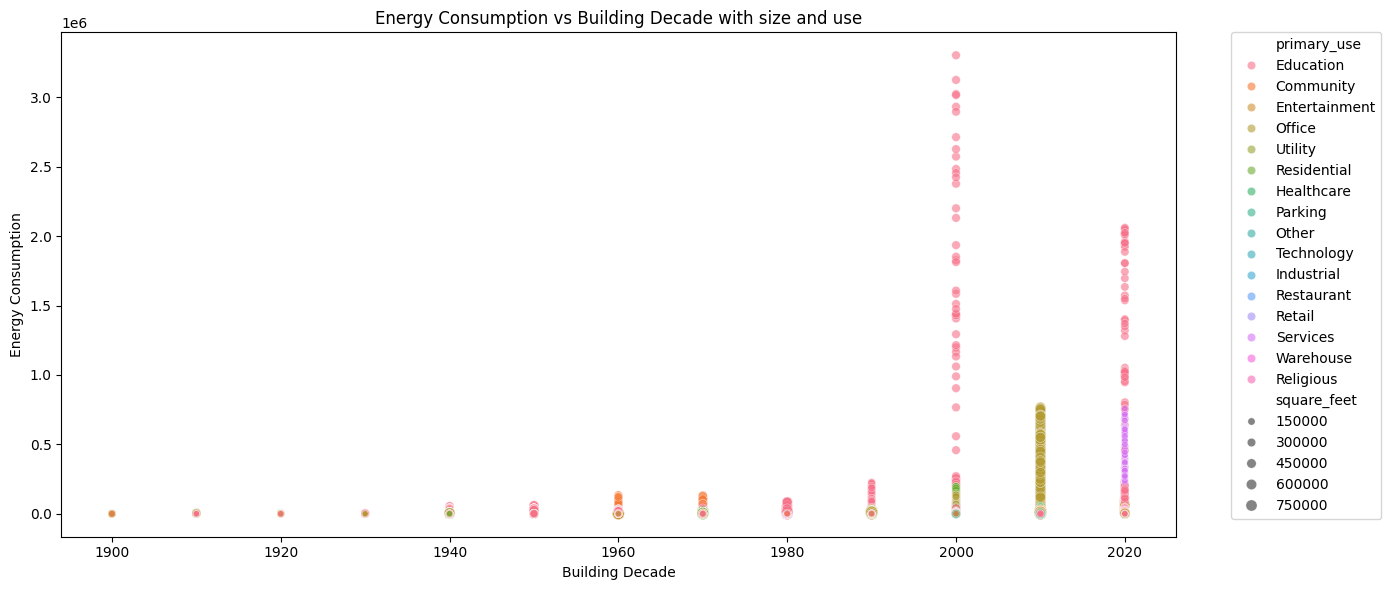

In [30]:
# visualization 1
# create scatterplot for decades to see the relationship between energy consumption with size and use
plt.figure(figsize=(14,6))
sns.scatterplot(
    data=pd_feature_df,
    x="decade",
    y="energy_consumption",
    hue="primary_use",
    size="square_feet",
    alpha=0.6
)
plt.title("Energy Consumption vs Building Decade with size and use")
plt.xlabel("Building Decade")
plt.ylabel("Energy Consumption")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()

### Discussion about Plot 2 
This chart compares the average energy consumption (bars) and average air temperature (line) across 16 sites.  

We can observe the significant variation in energy consumption, with sites 7 and 13 recording the highest levels, while sites 5, 8, and 10 show much lower consumption. Furthermore, high energy use does not always correlate with temperature. For example, while the most two consumed sites are all colder sites overall, some colder sites, such as site 11, exhibit relatively low consumption, and also warmer sites do not consume more energy due to the cooling demand. 

Overall, the findings from this visualization suggest that while climate has some influence, it is not the primary factor.  Instead, site-specific characteristics such as building density, primary use, and operational requirements might play a more significant role in determining total energy consumption.

In [31]:
# get average temperature for each site
avg_temp_site = (pd_feature_df.groupby("site_id").agg(avg_energy=("energy_consumption", "mean"),
                                                 avg_temp=("air_temperature", "mean")).reset_index())

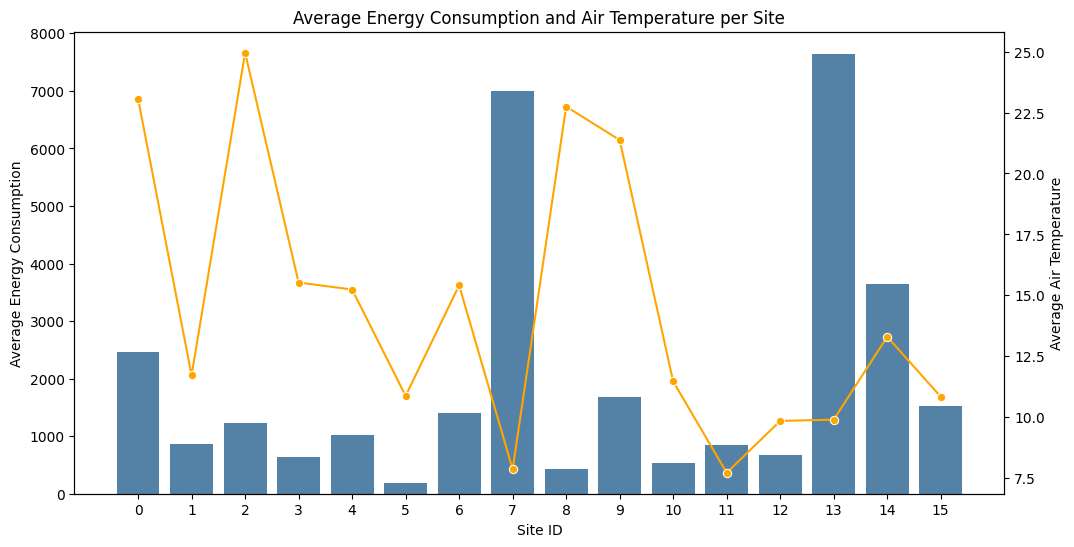

In [32]:
# visualization 2

# create chart see the relationships between energy consumption and each site and its avg temp
fig, ax1 = plt.subplots(figsize=(12,6))

# energy comsumption for each site
sns.barplot(
    data=avg_temp_site,
    x="site_id",
    y="avg_energy",
    color="steelblue",
    ax=ax1
)
ax1.set_ylabel("Average Energy Consumption")
ax1.set_xlabel("Site ID")
ax1.set_title("Average Energy Consumption and Air Temperature per Site")

# temperature for each site
ax2 = ax1.twinx()
sns.lineplot(
    data=avg_temp_site,
    x="site_id",
    y="avg_temp",
    marker="o",
    color="orange",
    ax=ax2
)
ax2.set_ylabel("Average Air Temperature")

plt.show()

## Part 2. Feature extraction and ML training <a class="anchor" name="part-2"></a>
In this section, you must use PySpark DataFrame functions and ML packages for data preparation, model building, and evaluation. Other ML packages, such as scikit-learn, should not be used to process the data; however, it’s fine to use them to display the result or evaluate your model.  
### 2.1 Discuss the feature selection and prepare the feature columns

2.1.1 Based on the data exploration from 1.2 and considering the use case, discuss the importance of those features (For example, which features may be useless and should be removed, which feature has a significant impact on the label column, which should be transformed), which features you are planning to use? Discuss the reasons for selecting them and how you plan to create/transform them.  
○	300 words max for the discussion  
○	Please only use the provided data for model building  
○	You can create/add additional features based on the dataset  
○	Hint - Use the insights from the data exploration/domain knowledge/statistical models to consider whether to create more feature columns, whether to remove some columns  

###  discussion
numerical features: all variables will be retained. Square_feet feature shows a highly skewed distribution, and therefore a log transformation will be performed to reduce the effect of extreme values. Other numerical variables will be preserved in their original form.

non-numerical data: primary_use and meter_type will be treated as categorical variables and transformed using one-hot encoding. Both time_interval and wind_direction are cyclical in nature and will be encoded using sine and cosine transformations to preserve their periodic properties.

date variables: year column will be removed as it only contains 2022. Although peak/off-peak labels already capture seasonal effects, the month variable will also be preserved through cyclical encoding (sine and cosine) to retain finer seasonal variations. The day column will be dropped due to limited predictive power and the high dimensionality that one-hot encoding would generate. The year_built column will be aggregated into decades units to capture chronological effects while avoiding noise.

latent features: latent_y, latent_s, and latent_r, their meaning is unclear. We will include them in the model for testing first, and then decide whether to remove them.

identifiers: such as row_id and building_id will be excluded since they provide no explanatory power and may lead to overfitting.

2.1.2 Write code to create/transform the columns based on your discussion above.

In [33]:
# numerical features 
# log transformation
feature_df = feature_df.withColumn("log_square_feet", F.log1p("square_feet"))

In [34]:
# non-numerical features
# OHE
for col in ["primary_use", "meter_type"]:
    indexer = StringIndexer(inputCol=col, outputCol=col + "_idx", handleInvalid="keep")
    encoder = OneHotEncoder(inputCols=[col + "_idx"], outputCols=[col + "_ohe"])
    feature_df = indexer.fit(feature_df).transform(feature_df)
    feature_df = encoder.fit(feature_df).transform(feature_df)

In [35]:
# cyclical encoding
# time_interval
# transfer to numerical 
feature_df = feature_df.withColumn(
    "time_interval_num",
    F.when(F.col("time_interval") == "0:00-5:59", 0)
     .when(F.col("time_interval") == "6:00-11:59", 1)
     .when(F.col("time_interval") == "12:00-17:59", 2)
     .when(F.col("time_interval") == "18:00-23:59", 3)
     .otherwise(None)
)

feature_df = feature_df.withColumn("time_sin",F.sin(2 * math.pi * F.col("time_interval_num") / 4))
feature_df = feature_df.withColumn("time_cos", F.cos(2 * math.pi * F.col("time_interval_num") / 4))

# wind_direction
feature_df = feature_df.withColumn("wind_dir_sin", F.sin(2 * math.pi * F.col("wind_direction")/360))
feature_df = feature_df.withColumn("wind_dir_cos", F.cos(2 * math.pi * F.col("wind_direction")/360))

In [36]:
# date features
# drop year (only 2022)
feature_df = feature_df.drop("year")

# month cyclical encoding
feature_df = feature_df.withColumn("month_sin", F.sin(2 * math.pi * F.col("month")/12))
feature_df = feature_df.withColumn("month_cos", F.cos(2 * math.pi * F.col("month")/12))

# drop day
feature_df = feature_df.drop("day")

# group year_built by decades
feature_df = feature_df.withColumn("decade", (F.col("year_built")/10).cast("int")*10)

In [37]:
# drop identifiers
feature_df = feature_df.drop("row_id", "building_id")

In [38]:
# check the final features
feature_df.printSchema()

root
 |-- site_id: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- time_interval: string (nullable = false)
 |-- meter_type: string (nullable = true)
 |-- energy_consumption: double (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: double (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: double (nullable = true)
 |-- peak/off-peak: string (nullable = false)
 |-- air_temperature: double (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: double (nullable = true)
 |-- sea_level_pressure: double (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- log_square_feet: double (nullable = true)
 |-- primary_use_idx: double (nullable = false)
 |-- primary_use_ohe: vector (nullable = true)
 |-- meter_type_idx

### 2.2 Preparing Spark ML Transformers/Estimators for features, labels, and models  <a class="anchor" name="2.2"></a>

**2.2.1 Write code to create Transformers/Estimators for transforming/assembling the columns you selected above in 2.1 and create ML model Estimators for Random Forest (RF) and Gradient-boosted tree (GBT) model.
Please DO NOT fit/transform the data yet.**

In [39]:
# input
assemblerInputs = ["log_square_feet", "floor_count", "decade","air_temperature", "dew_temperature",
                   "sea_level_pressure", "wind_speed", "cloud_coverage","wind_dir_sin", "wind_dir_cos", 
                   "time_sin", "time_cos", "month_sin", "month_cos","primary_use_ohe", "meter_type_ohe",
                   "latent_y", "latent_s", "latent_r"]

# VectorAssembler
assembler = VectorAssembler(inputCols=assemblerInputs, outputCol="features")

# Label
labelCol = "energy_consumption"

**2.2.2. Write code to include the above Transformers/Estimators into two pipelines.
Please DO NOT fit/transform the data yet.**

In [40]:
# Random Forest
rf = RandomForestRegressor(featuresCol="features", labelCol=labelCol, maxDepth=3, numTrees=10)

# Gradient Boosted Tree
gbt = GBTRegressor( featuresCol="features", labelCol=labelCol, maxDepth=3, maxIter=10)

rf_pipeline = Pipeline(stages=[assembler, rf])
gbt_pipeline = Pipeline(stages=[assembler, gbt])

### 2.3 Preparing the training data and testing data  
Write code to split the data for training and testing, using 2025 as the random seed. You can decide the train/test split ratio based on the resources available on your laptop.  
Note: Due to the large dataset size, you can use random sampling (say 20% of the dataset). 

In [41]:
# random sampling
sampled_df = feature_df.sample(withReplacement=False, fraction=0.05, seed=2025)

# split into train/test sets
train_df, test_df = sampled_df.randomSplit([0.8, 0.2], seed=2025)

### 2.4 Training and evaluating models  
2.4.1 Write code to use the corresponding ML Pipelines to train the models on the training data from 2.3. And then use the trained models to predict the testing data from 2.3

In [42]:
# train rf pipeline
rf_model = rf_pipeline.fit(train_df)
rf_predictions = rf_model.transform(test_df)

# train GBT pipeline
gbt_model = gbt_pipeline.fit(train_df)
gbt_predictions = gbt_model.transform(test_df)

2.4.2 For both models (RF and GBT): with the test data, decide on which metrics to use for model evaluation and discuss which one is the better model (no word limit; please keep it concise). You may also use a plot for visualisation (not mandatory).

In [43]:
# Define evaluators
rmse_evaluator = RegressionEvaluator(labelCol="energy_consumption", predictionCol="prediction", metricName="rmse")
mae_evaluator = RegressionEvaluator(labelCol="energy_consumption", predictionCol="prediction", metricName="mae")
r2_evaluator = RegressionEvaluator(labelCol="energy_consumption", predictionCol="prediction", metricName="r2")

# create function to calculate RMSLE
def rmsle(df, labelCol="energy_consumption", predictionCol="prediction"):
    # take log for prediction and target
    df_log = df.withColumn("log_pred", F.log1p(F.col(predictionCol))) \
               .withColumn("log_label", F.log1p(F.col(labelCol)))
    return df_log.select(F.sqrt(F.mean((F.col("log_pred") - F.col("log_label"))**2))).collect()[0][0]

# RF model
rf_rmse = rmse_evaluator.evaluate(rf_predictions)
rf_mae = mae_evaluator.evaluate(rf_predictions)
rf_r2  = r2_evaluator.evaluate(rf_predictions)
rf_rmsle = rmsle(rf_predictions)
print("Random Forest - RMSE:", rf_rmse)
print("Random Forest - MAE :", rf_mae)
print("Random Forest - R²  :", rf_r2)
print("Random Forest - RMSLE:", rf_rmsle)

# GBT model
gbt_rmse = rmse_evaluator.evaluate(gbt_predictions)
gbt_mae = mae_evaluator.evaluate(gbt_predictions)
gbt_r2  = r2_evaluator.evaluate(gbt_predictions)
gbt_rmsle = rmsle(gbt_predictions)
print("GBT - RMSE:", gbt_rmse)
print("GBT - MAE :", gbt_mae)
print("GBT - R²  :", gbt_r2)
print("GBT - RMSLE:", gbt_rmsle)


26/06/24 14:09:49 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Random Forest - RMSE: 15918.684075816109
Random Forest - MAE : 2523.663993177556
Random Forest - R²  : 0.1788713884449571
Random Forest - RMSLE: 2.783056799566355


26/06/24 14:10:01 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/06/24 14:10:01 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


GBT - RMSE: 14630.530505852217
GBT - MAE : 2237.878339158458
GBT - R²  : 0.3063873493762955
GBT - RMSLE: 2.4656068267201476


After evaluation above, all metrics in the GBT model outperformed those in the Random Forest model. Therefore, I decided to save the GBT model.

2.4.3 3.	Save the better model (you’ll need it for the streaming pipeline).
(Note: You may need to go through a few training loops or use more data to create a better-performing model.)

In [44]:
# Save GBT model as better model
# use overwrite to prevent error given that file existed 
gbt_model.write().overwrite().save("models/energy_pipeline_model")

### Part 3. Hyperparameter Tuning and Model Optimisation <a class="anchor" name="part-3"></a>  
Apply the techniques you have learnt from the labs, for example, CrossValidator, TrainValidationSplit, ParamGridBuilder, etc., to perform further hyperparameter tuning and model optimisation.  
The assessment is based on the quality of your work/process, not the quality of your model. Please include your thoughts/ideas/discussions.

#### Discussion about Hyperparameter Tuning Process:

From the previous stage, I choosed Gradient-Boosted Trees as the base model and applied CrossValidator with 3-fold cross-validation to search for the best hyperparameters. The tuning process aimed to reduce the RMSLE on the validation set.

#### Parameters tuned and tested ranges:
Overall, the parameter ranges were kept relatively small in order to control model training time and avoid memory overload during cross-validation.

`maxDepth`: [2, 4, 6]  
Rational: Tune the parameter of maxDepth to find the best parameter that can catch enough interactions and won't overfit.

`maxIter`: [10, 20, 50]  
Rational: Tune the parameter of maxIter to get a balance between accuracy and computational cost.

`stepSize`: [0.05, 0.1, 0.2] 
Rational: Tune the parameter of stepSize to explore the trade-off between stability and efficiency. 

#### Evaluation metric:
Since `RegressionEvaluator` in PySpark does not support RMSLE directly, we first used RMSE as the evaluation metric during cross-validation to identify the best hyperparameters. After selecting the best model, we then applied a custom RMSLE function on the test dataset to evaluate its performance.

#### Results and discussion:
The best model was obtained with `maxDepth=4`, `maxIter=50`, and `stepSize=0.05`.  

Then, we apply this model on the test set, we can see that compared to the baseline GBT model, the RMSLE improved from **2.57 to 2.42**, indicating that moderately deep trees with more iterations and a smaller learning rate can capture additional variance while avoiding overfitting.  

In summary, hyperparameter tuning improved the model’s predictive accuracy and showed the importance of get a balance between model complexity, convergence stability, and generalisation when we are creating a model.


In [45]:
# create ParamGrid for Cross Validation
# NOTE: trimmed grid (4 combos x 3 folds = 12 GBT fits) so it completes on a
# single-machine local[*] run. Original 27-combo grid (81 fits) was intractable here.
gbtParamGrid = (ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.maxIter, [10, 20])
    .addGrid(gbt.stepSize, [0.1])
    .build())

In [46]:
# define an evaluator for evaluating the model 
gbtEvaluator = RegressionEvaluator(
    labelCol="energy_consumption",
    predictionCol="prediction",
    metricName="rmse"
)

In [47]:
# 3-fold Cross Validation
gbtCV = CrossValidator(
    estimator=gbt_pipeline,
    estimatorParamMaps=gbtParamGrid,
    evaluator=gbtEvaluator,  
    numFolds=3,
    seed=2025 # # fix the outcome
)

In [48]:
# Run cross validations
gbtCVModel = gbtCV.fit(train_df)

In [49]:
# get the best model and check the result
best_model = gbtCVModel.bestModel
print('Best Param for GBT: ', best_model.stages[-1]._java_obj.paramMap())

Best Param for GBT:  {
	GBTRegressor_98bd0791b3bd-featuresCol: features,
	GBTRegressor_98bd0791b3bd-labelCol: energy_consumption,
	GBTRegressor_98bd0791b3bd-maxDepth: 5,
	GBTRegressor_98bd0791b3bd-maxIter: 10,
	GBTRegressor_98bd0791b3bd-stepSize: 0.1
}


In [50]:
# get prediction from test dataset
cv_predictions = gbtCVModel.transform(test_df)

# calculate rmsle
rmsle_score = rmsle(cv_predictions)

# print the result
print("Tuned GBT RMSLE:", rmsle_score)

Tuned GBT RMSLE: 2.3654327203787835


In [51]:
# overwrite the model to the filesystem
best_model.write().overwrite().save('models/energy_pipeline_model')